In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41357,Workers: 12
Dashboard: http://127.0.0.1:8787/status,Total threads: 96
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:33797,Total threads: 8
Dashboard: http://127.0.0.1:44283/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:39345,


In [2]:
iter = 22
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/sep2012/validate_fwd/iter' + str(iter) + '/'

In [57]:
import xarray as xr
profile_path = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/PROF_eq/NODC_TP_2012_MRB_w_model.nc'
ds = xr.open_dataset(profile_path)

In [58]:
ds.prof_lon.values

array([ 155.95,  155.95,  155.95, ...,    0.  , -139.88, -139.88])

In [59]:
import pandas as pd

dates = ds['prof_YYYYMMDD'].values.astype(int)
times = ds['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')
ds = ds.assign_coords(time=("iPROF", datetimes))

ds = ds.assign_coords(
    lon = ("iPROF", ((ds.prof_lon / 0.25).round() * 0.25).data),
    lat = ("iPROF", ((ds.prof_lat / 0.25).round() * 0.25).data)
)

# Assign as coordinate and optionally swap dimensions
ds = ds.assign_coords(time=('iPROF', datetimes))
ds = ds.assign_coords(depth=('iDEPTH', ds['prof_depth'].values*-1))
ds = ds.swap_dims({'iPROF': 'time'})

In [60]:
ts_by_lon = ds.groupby("lon")
ts_by_lon.groups.keys()

dict_keys([-180.0, -179.75, -170.0, -155.0, -140.25, -140.0, -139.75, -125.0, -124.75, -124.5, -124.25, -115.0, -114.75, -114.5, -114.25, -114.0, -113.75, -113.5, -113.25, -113.0, -112.75, -112.5, -112.25, -112.0, -111.75, -111.5, -111.25, -111.0, -110.75, -110.5, -110.25, -110.0, -109.75, -108.75, -108.5, -108.25, -95.5, -95.25, -95.0, -94.75, -94.5, -94.25, -94.0, -93.75, -93.5, 0.0, 130.0, 130.25, 136.5, 137.25, 138.0, 138.25, 147.0, 156.0, 160.25, 160.5, 161.0, 161.5, 161.75, 162.0, 162.5, 162.75, 163.0, 163.5, 163.75, 164.0, 164.25, 164.75, 165.0, 165.25, 180.0])

In [61]:
ts_by_lon[-140.0]

<xarray.Dataset> Size: 5MB
Dimensions:        (iPROF: 1529, iDEPTH: 36)
Coordinates:
    time           (iPROF) datetime64[ns] 12kB 2012-01-01 ... 2012-12-31
    lon            (iPROF) float64 12kB -140.0 -140.0 -140.0 ... -140.0 -140.0
    lat            (iPROF) float64 12kB 2.0 2.0 2.0 2.0 ... -0.0 -0.0 0.0 0.0
    depth          (iDEPTH) float64 288B -1.0 -2.0 -5.0 ... -400.0 -500.0 -750.0
Dimensions without coordinates: iPROF, iDEPTH
Data variables: (12/19)
    prof_T         (iPROF, iDEPTH) float64 440kB ...
    prof_Terr      (iPROF, iDEPTH) float64 440kB ...
    prof_Testim    (iPROF, iDEPTH) float64 440kB ...
    prof_Tflag     (iPROF, iDEPTH) float64 440kB ...
    prof_Tweight   (iPROF, iDEPTH) float64 440kB ...
    prof_S         (iPROF, iDEPTH) float64 440kB ...
    ...             ...
    prof_lon       (iPROF) float64 12kB -140.0 -140.0 -140.0 ... -139.9 -139.9
    prof_date      (iPROF) float64 12kB ...
    prof_basin     (iPROF) float64 12kB ...
    prof_point     (iPROF) float64 12kB ...
    prof_depth     (iDEPTH) float64 288B 1.0 2.0 5.0 10.0 ... 400.0 500.0 750.0
    prof_descr     (iPROF) |S30 46kB ...
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     06-Oct-2025

In [67]:
import numpy as np
import warnings
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13


ValueError: The input coordinate is not sorted in increasing order along axis 0. This can lead to unexpected results. Consider calling the `sortby` method on the input DataArray. To plot data with categorical axes, consider using the `heatmap` function from the `seaborn` statistical plotting library.

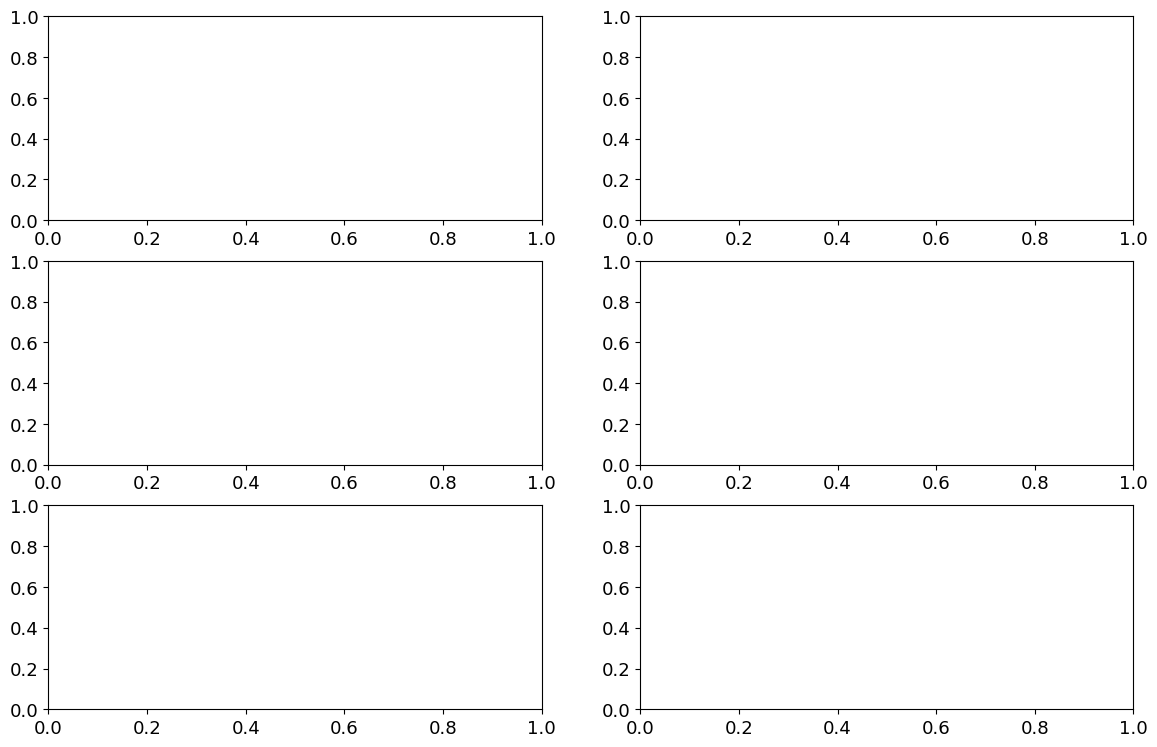

In [66]:
fig, ax = plt.subplots(figsize=(14,9),nrows=3, ncols=2)
ts_by_lon[-140.0].prof_T.plot(ax=ax[0,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('TAO T 140W')
ax[0,0].set_ylabel('Z (m)')
ts_by_lon[-140.0].prof_Testim.plot(ax=ax[1,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T 140W')
diff = ts_by_lon[-140.0].prof_Testim - ts_by_lon[-140.0].prof_T
diff.plot(ax=ax[2,0],x='iPROF',y='depth',cmap=cmo.balance,vmin=-3.5,vmax=3.5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T 140W')
ax[2,0].set_ylabel('Z (m)')

ts_by_lon[-140.0].prof_S.plot(ax=ax[0,1],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,1].set_title('TAO S')
ax[0,1].set_ylabel('Z (m)')
ts_by_lon[-140.0].prof_Sestim.plot(ax=ax[1,1],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,1].set_ylabel('Z (m)')
ax[1,1].set_title('Iter'+ str(iter)+' S 140W')
diff = ts_by_lon[-140.0].prof_Sestim - ts_by_lon[-140.0].prof_S
diff.plot(ax=ax[2,1],x='iPROF',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) S 140W')
ax[2,1].set_ylabel('Z (m)')

plt.tight_layout()
filename = foldername + 'TAO_TS_profiles_vs_iter'+ str(iter)+'_140W.png'
plt.savefig(filename)

In [64]:
def slice_by_time_keep_lon(group, start_time):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

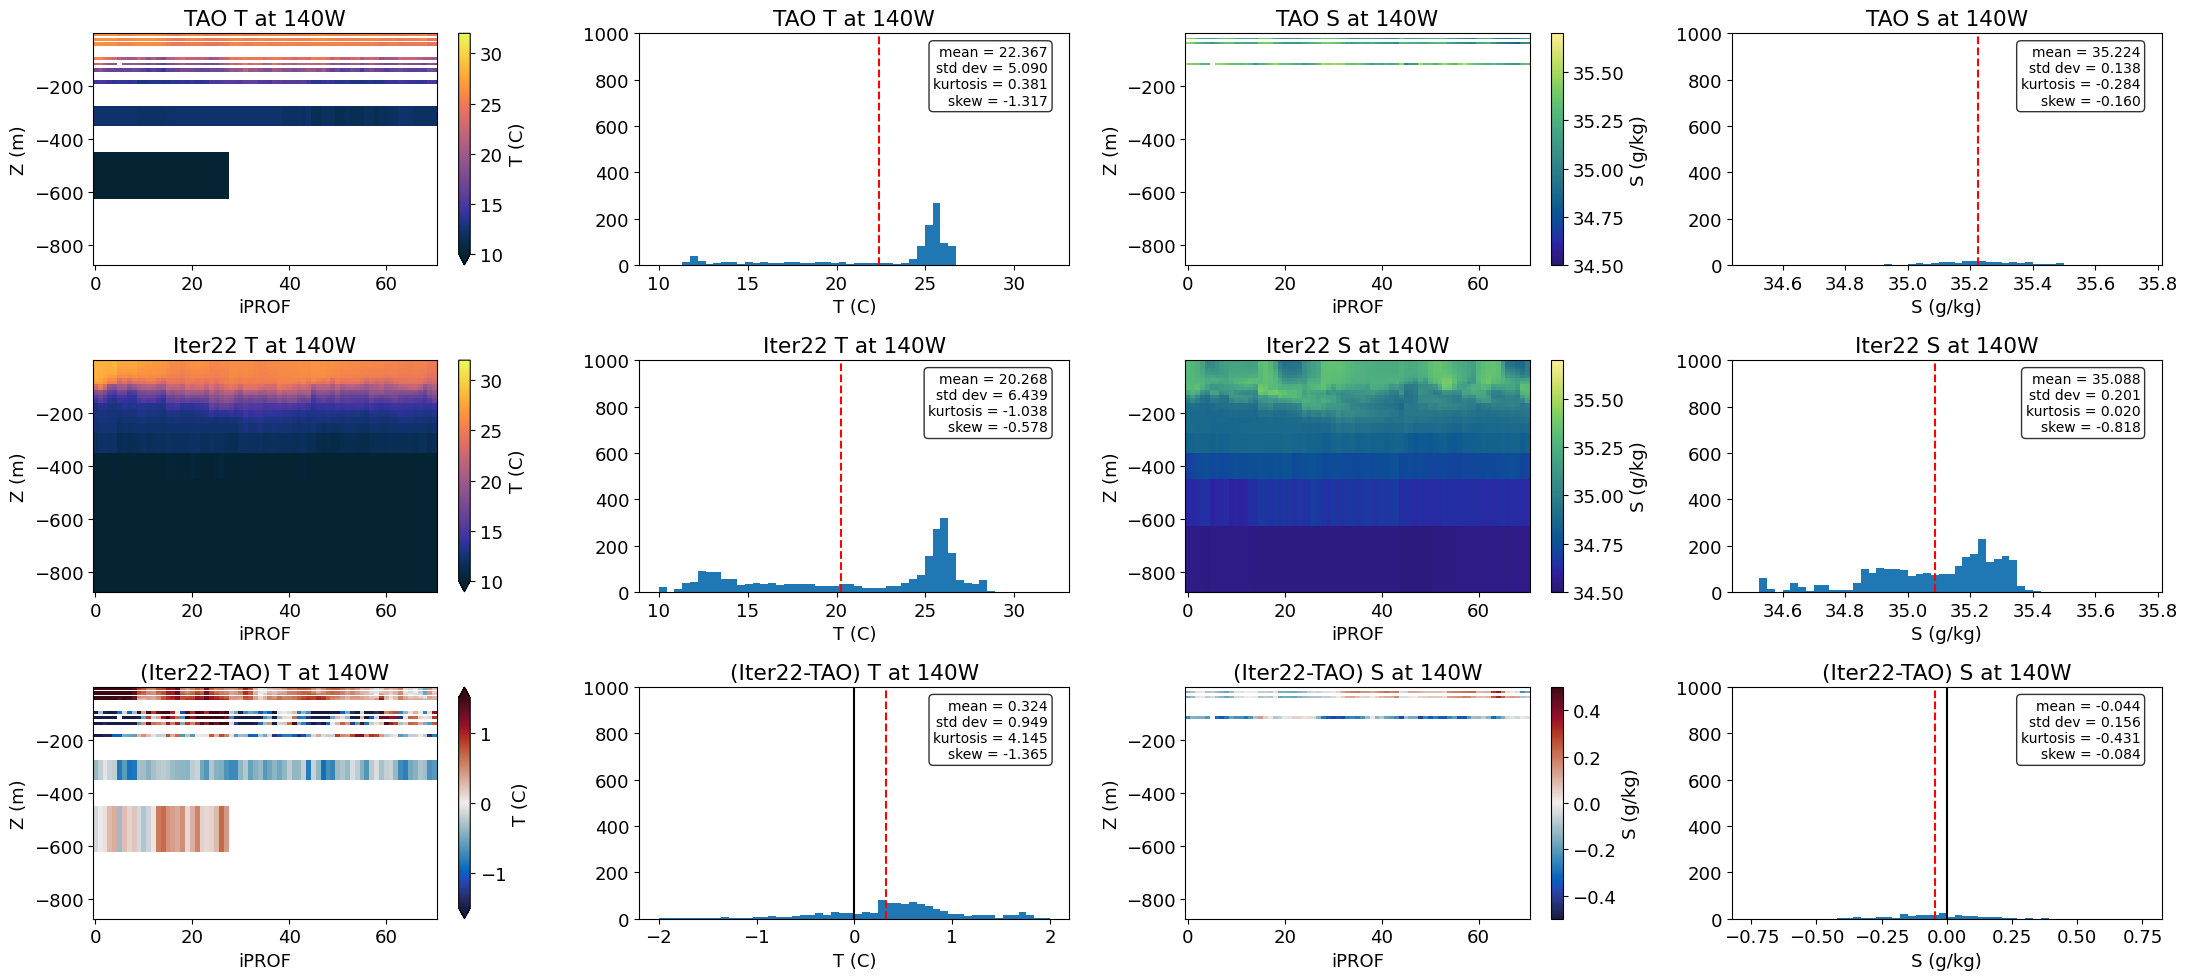

In [90]:
from scipy.stats import kurtosis, skew
vmin = 10
vmax = 32
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ts_by_lon_subset = slice_by_time_keep_lon(ts_by_lon[-140.0], "2012-09-01")
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat < 0.5, drop=True)
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat > -0.5, drop=True)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ts_by_lon_subset.prof_T.plot(ax=ax[0,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('TAO T at 140W')
ax[0,0].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Testim.plot(ax=ax[1,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 140W')
diff = ts_by_lon_subset.prof_Testim - ts_by_lon_subset.prof_T
diff[:].plot(ax=ax[2,0],x='iPROF',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 140W')
ax[2,0].set_ylabel('Z (m)')


ts_by_lon_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,1000)
ax[0,1].set_title('TAO T at 140W')
ax[0,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_T.mean().values
std_u = ts_by_lon_subset.prof_T.std().values
flat_nonan = ts_by_lon_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 140W')
ax[1,1].set_ylim(0,1000)
ax[1,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_Testim.mean().values
std_u = ts_by_lon_subset.prof_Testim.std().values
flat_nonan = ts_by_lon_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

vmin = -2
vmax = 2
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 140W')
ax[2,1].set_ylim(0,1000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- S ------------
vmin = 34.5
vmax = 35.75
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ts_by_lon_subset.prof_S.plot(ax=ax[0,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('TAO S at 140W')
ax[0,2].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Sestim.plot(ax=ax[1,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 140W')
diff = ts_by_lon_subset.prof_Sestim - ts_by_lon_subset.prof_S
diff[:].plot(ax=ax[2,2],x='iPROF',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 140W')
ax[2,2].set_ylabel('Z (m)')


ts_by_lon_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,1000)
ax[0,3].set_title('TAO S at 140W')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_S.mean().values
std_u = ts_by_lon_subset.prof_S.std().values
flat_nonan = ts_by_lon_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 140W')
ax[1,3].set_ylim(0,1000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_Sestim.mean().values
std_u = ts_by_lon_subset.prof_Sestim.std().values
flat_nonan = ts_by_lon_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

vmin = -0.75
vmax = 0.75
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 140W')
ax[2,3].set_ylim(0,1000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'TAO_TS_vs_Iter' + str(iter) + '_hist_140W.png'
plt.savefig(filename)

In [14]:
print(ts_by_lon_subset.depth)

<xarray.DataArray 'depth' (iDEPTH: 62)> Size: 496B
array([ -10.,  -15.,  -20.,  -25.,  -30.,  -35.,  -40.,  -45.,  -50.,
        -55.,  -60.,  -65.,  -70.,  -75.,  -80.,  -85.,  -90.,  -95.,
       -100., -105., -110., -115., -120., -125., -130., -135., -140.,
       -145., -150., -155., -160., -165., -170., -175., -180., -185.,
       -190., -195., -200., -205., -210., -215., -220., -225., -230.,
       -235., -240., -245., -250., -255., -260., -265., -270., -275.,
       -280., -285., -290., -295., -300., -305., -310., -315.])
Coordinates:
    depth    (iDEPTH) float64 496B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
Dimensions without coordinates: iDEPTH


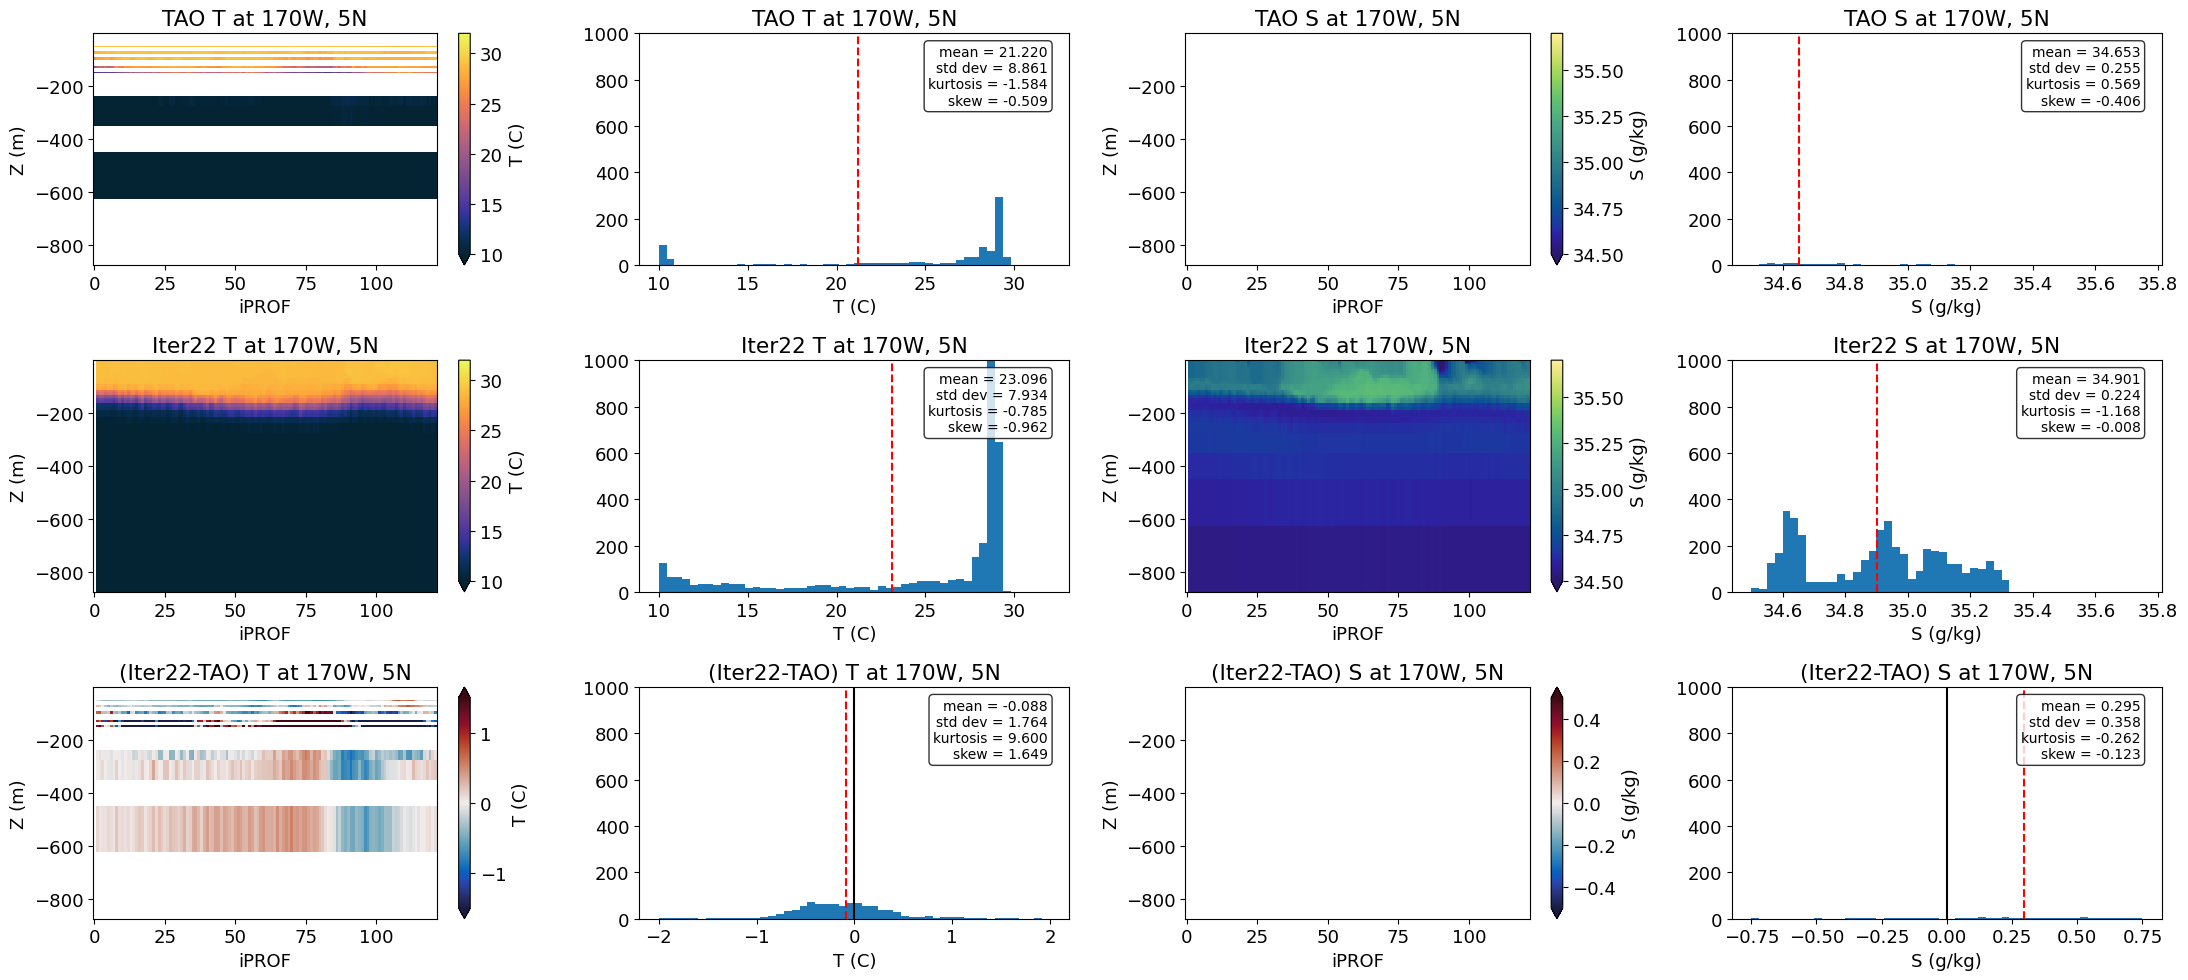

In [95]:
from scipy.stats import kurtosis, skew
vmin = 10
vmax = 32
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ts_by_lon_subset = slice_by_time_keep_lon(ts_by_lon[-170.0], "2012-09-01")
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat < 5.5, drop=True)
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat > 4.5, drop=True)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ts_by_lon_subset.prof_T.plot(ax=ax[0,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('TAO T at 170W, 5N')
ax[0,0].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Testim.plot(ax=ax[1,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 170W, 5N')
diff = ts_by_lon_subset.prof_Testim - ts_by_lon_subset.prof_T
diff[:].plot(ax=ax[2,0],x='iPROF',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 170W, 5N')
ax[2,0].set_ylabel('Z (m)')


ts_by_lon_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,1000)
ax[0,1].set_title('TAO T at 170W, 5N')
ax[0,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_T.mean().values
std_u = ts_by_lon_subset.prof_T.std().values
flat_nonan = ts_by_lon_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 170W, 5N')
ax[1,1].set_ylim(0,1000)
ax[1,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_Testim.mean().values
std_u = ts_by_lon_subset.prof_Testim.std().values
flat_nonan = ts_by_lon_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

vmin = -2
vmax = 2
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 170W, 5N')
ax[2,1].set_ylim(0,1000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- S ------------
vmin = 34.5
vmax = 35.75
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ts_by_lon_subset.prof_S.plot(ax=ax[0,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('TAO S at 170W, 5N')
ax[0,2].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Sestim.plot(ax=ax[1,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 170W, 5N')
diff = ts_by_lon_subset.prof_Sestim - ts_by_lon_subset.prof_S
diff[:].plot(ax=ax[2,2],x='iPROF',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 170W, 5N')
ax[2,2].set_ylabel('Z (m)')


ts_by_lon_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,1000)
ax[0,3].set_title('TAO S at 170W, 5N')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_S.mean().values
std_u = ts_by_lon_subset.prof_S.std().values
flat_nonan = ts_by_lon_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 170W, 5N')
ax[1,3].set_ylim(0,1000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_Sestim.mean().values
std_u = ts_by_lon_subset.prof_Sestim.std().values
flat_nonan = ts_by_lon_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

vmin = -0.75
vmax = 0.75
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 170W, 5N')
ax[2,3].set_ylim(0,1000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'TAO_TS_vs_Iter' + str(iter) + '_hist_170W5N.png'
plt.savefig(filename)

In [96]:
ts_by_lon_subset = slice_by_time_keep_lon(ts_by_lon[-110.0], "2012-09-01")
ts_by_lon_subset.lat

<xarray.DataArray 'lat' (iPROF: 284)> Size: 2kB
array([ 5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,  5.  ,
        5.  ,  5.  ,  5.  ,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,  5.25,
        5.25,  5.25,  5.25,  5.25,  5.25,  2.  ,  2.  ,  2.  ,  2.  ,
        2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,
        2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,
        2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,
        2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,  2.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  , -8.  ,
       -8.  , -8.  , -8.  , -8.  , -8.  ])
Coordinates:
    time     (iPROF) datetime64[ns] 2kB 2012-09-01 2012-09-02 ... 2012-12-31
    lon      (iPROF) float64 2kB -110.0 -110.0 -110.0 ... -110.0 -110.0 -110.0
    lat      (iPROF) float64 2kB 5.0 5.0 5.0 5.0 5.0 ... -8.0 -8.0 -8.0 -8.0
Dimensions without coordinates: iPROF

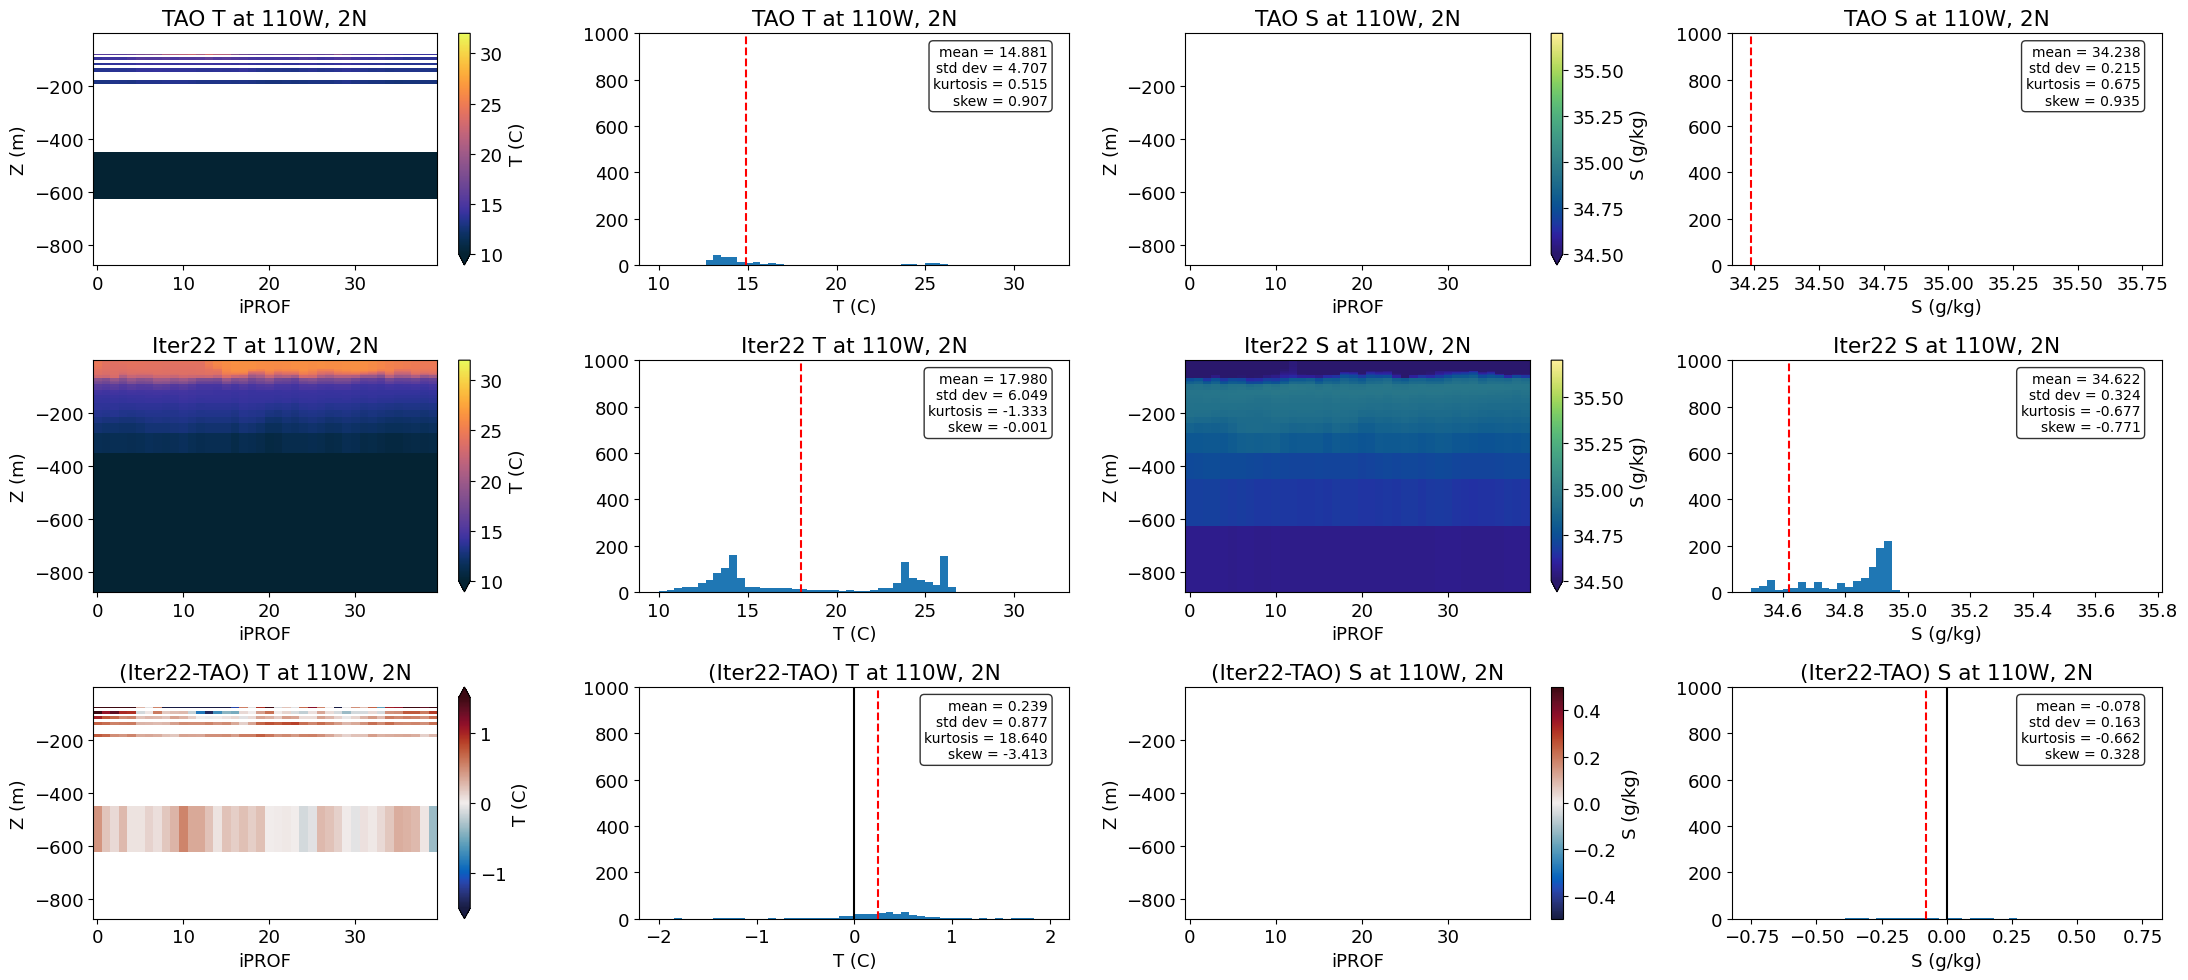

In [97]:
from scipy.stats import kurtosis, skew
vmin = 10
vmax = 32
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ts_by_lon_subset = slice_by_time_keep_lon(ts_by_lon[-110.0], "2012-09-01")
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat < 2.25, drop=True)
ts_by_lon_subset = ts_by_lon_subset.where(ts_by_lon_subset.lat > 1.75, drop=True)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ts_by_lon_subset.prof_T.plot(ax=ax[0,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('TAO T at 110W, 2N')
ax[0,0].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Testim.plot(ax=ax[1,0],x='iPROF',y='depth',cmap=cmo.thermal,vmin=10,vmax=32,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 110W, 2N')
diff = ts_by_lon_subset.prof_Testim - ts_by_lon_subset.prof_T
diff[:].plot(ax=ax[2,0],x='iPROF',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 110W, 2N')
ax[2,0].set_ylabel('Z (m)')


ts_by_lon_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,1000)
ax[0,1].set_title('TAO T at 110W, 2N')
ax[0,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_T.mean().values
std_u = ts_by_lon_subset.prof_T.std().values
flat_nonan = ts_by_lon_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 110W, 2N')
ax[1,1].set_ylim(0,1000)
ax[1,1].set_xlabel('T (C)')
mean_u = ts_by_lon_subset.prof_Testim.mean().values
std_u = ts_by_lon_subset.prof_Testim.std().values
flat_nonan = ts_by_lon_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

vmin = -2
vmax = 2
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 110W, 2N')
ax[2,1].set_ylim(0,1000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- S ------------
vmin = 34.5
vmax = 35.75
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ts_by_lon_subset.prof_S.plot(ax=ax[0,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('TAO S at 110W, 2N')
ax[0,2].set_ylabel('Z (m)')
ts_by_lon_subset.prof_Sestim.plot(ax=ax[1,2],x='iPROF',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.7,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 110W, 2N')
diff = ts_by_lon_subset.prof_Sestim - ts_by_lon_subset.prof_S
diff[:].plot(ax=ax[2,2],x='iPROF',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 110W, 2N')
ax[2,2].set_ylabel('Z (m)')


ts_by_lon_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,1000)
ax[0,3].set_title('TAO S at 110W, 2N')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_S.mean().values
std_u = ts_by_lon_subset.prof_S.std().values
flat_nonan = ts_by_lon_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ts_by_lon_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 110W, 2N')
ax[1,3].set_ylim(0,1000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ts_by_lon_subset.prof_Sestim.mean().values
std_u = ts_by_lon_subset.prof_Sestim.std().values
flat_nonan = ts_by_lon_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
# ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

vmin = -0.75
vmax = 0.75
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 110W, 2N')
ax[2,3].set_ylim(0,1000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'TAO_TS_vs_Iter' + str(iter) + '_hist_110W2N.png'
plt.savefig(filename)

In [98]:
client.shutdown()
cluster.close()
client.close()